In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import bacco
import deepdish as dd

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [4]:
npoints=30
ndim = 7
seed = 1997

In [27]:
bounds = np.array([
                   [0.9, 14.4],                      # WindEnergyIn1e51erg 
                   [3.7,14.8],                       # VariableWindVelFactor
                   [1.135,4.54],                     # MaxSfrTimescale
                   [np.log10(0.005),np.log10(0.5)],  # Density of Wind Recoupling
                   [np.log10(0.001), np.log10(2)],   # RadioFeedbackFactor
                   [0.05, 0.2],                      # BlackHoleFeedbackFactor
                   [10,40]                           # RadioFeedbackReiorientationFactor
                ])

labels = ['$e_w$', '$v_w$', '$t_*$', '$\\log_{10}(\\rho_r)$', '$\\log_{10}(\epsilon_{f,kin})$', '$\epsilon_{f,high}$', '$f_{\mathrm{re}}$']

print("Creating LH with {0} points in {1} dimensions".format(npoints, ndim))
_cpars = bacco.utils.latinhypercube( ndim, npoints, spread=True, seed=seed, max_niter=100000)
cpars = bounds[:,0] + _cpars * (bounds[:,1] - bounds[:,0])
cpars[:,3] = 10**cpars[:,3]
cpars[:,4] = 10**cpars[:,4]
dd.io.save( "/cosmos_storage/data_sharing/MN5_resims/cpars_{0}_{1}.h5".format(npoints, seed), {'cpars':cpars})

Creating LH with 30 points in 7 dimensions


In [29]:
load = dd.io.load("/cosmos_storage/data_sharing/MN5_resims/cpars_{0}_{1}.h5".format(npoints, seed))

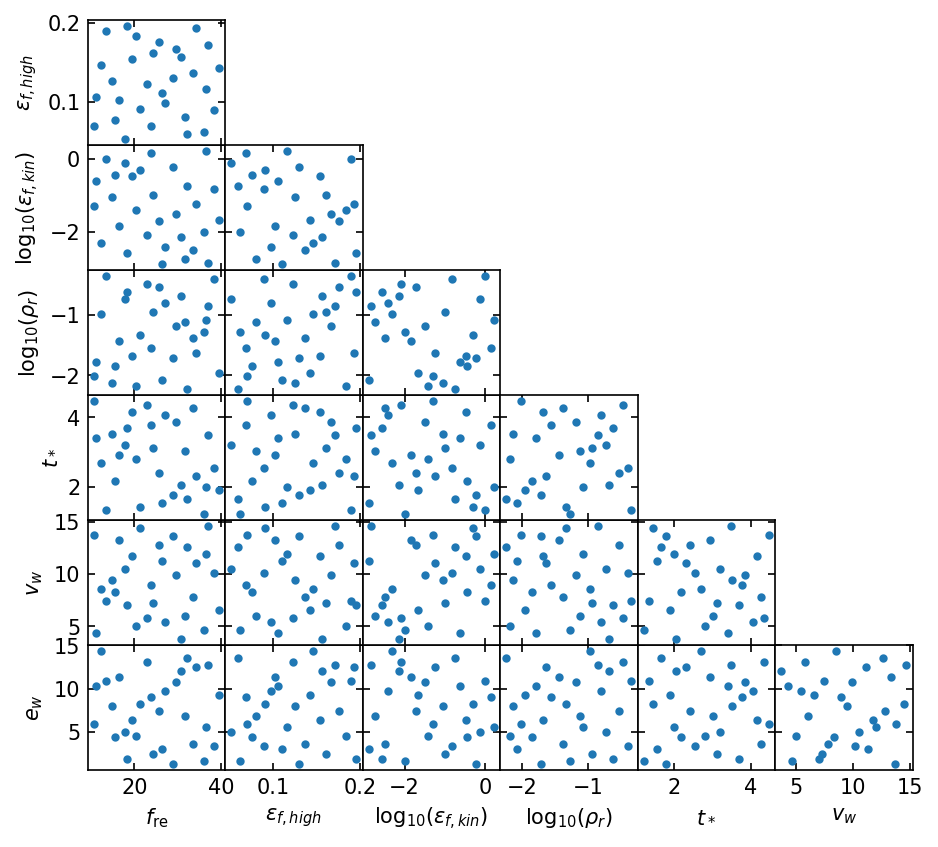

In [30]:
import matplotlib.pyplot as plt

# Create a figure
fig = plt.figure(dpi=150, figsize=(5.5, 5))


# Define the positions for the subplots
# Positions are normalized with respect to figure size
positions = []
N = 7
for i in range((N-1)):
    for j in range((N-1)-i):
        positions.append([i*1/(N-1), j*1/(N-1), 1/(N-1), 1/(N-1)])

ax = []
for i in range(int(N*(N-1)/2)):
    ax.append(fig.add_axes(positions[i]))

offset = 0
for i in range(N-1):
    for j in range((N-1)-i):
        if (N-1-i)==3 or (N-1-i)==4:
            if j==3 or j==4:
                ax[offset+j].plot(np.log10(cpars[:,N-1-i]), np.log10(cpars[:,j]), ls='', marker='o', ms=3)
            else:
                ax[offset+j].plot(np.log10(cpars[:,N-1-i]), cpars[:,j], ls='', marker='o', ms=3)
        else:
            if j==3 or j==4:
                ax[offset+j].plot(cpars[:,N-1-i], np.log10(cpars[:,j]), ls='', marker='o', ms=3)
            else:
                ax[offset+j].plot(cpars[:,N-1-i], cpars[:,j], ls='', marker='o', ms=3)
                
        if j==0:
            ax[offset+j].set_xlabel(labels[N-1-i])
        if i==0:
            ax[offset+j].set_ylabel(labels[j])
        if i!=0:
            ax[offset+j].set_yticklabels([])
        if j!=0:
            ax[offset+j].set_xticklabels([])

    offset += (N-1-i)


# Adjust layout
plt.show()
